# Homework — Regression and Classification: Error Analysis

**Course:** Introduction to Data Science
**Topic:** Systematic error analysis for regression and classification models

**Student name:** NOAM SHILO
**ID:** 322360975

---

We reuse the NBA player-season dataset from the previous assignments. The goal here
is not to build the best predictive model, but to systematically study **where and
why models fail** — through residuals, extreme errors, confusion matrices, and
threshold analysis — and to connect those failures back to real basketball meaning.

**Regression target:** `pts` (points per game), predicted from the player's other
season stats.
**Classification target:** whether a player-season has a **positive `net_rating`**
(1) or not (0) — i.e. can we tell, from individual stats, whether a player's team
did better with him on the court?


## 0. Setup and data preparation

In [1]:
# core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score, fbeta_score,
                              matthews_corrcoef, roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
DATA_PATH = r"D:\USER\Desktop\data sience\all_seasons.csv.csv"

In [2]:
# load the data, same cleaning as previous assignments
raw_df = pd.read_csv(DATA_PATH)
if raw_df.columns[0].lower().startswith("unnamed"):
    raw_df = raw_df.drop(columns=raw_df.columns[0])
df = raw_df.copy()
print("shape:", df.shape)
df.head()

shape: (12844, 21)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


### Choosing k for cross-validation

We use **k=5** for all cross-validation in this notebook. With 12,844 rows, each
fold still has about 2,570 samples for validation — enough to get a stable
estimate. A larger k (e.g. 10) would reduce bias slightly but increases
computation cost with 3+ regression models and hyperparameter comparisons; a
smaller k (e.g. 3) would leave less data per training fold and increase variance
of the estimate. k=5 is the standard, well-tested middle ground for a dataset of
this size.

In [3]:
# feature set: numeric player stats, excluding the two targets we will predict
all_numeric = df.select_dtypes(include="number").columns.tolist()
reg_target = "pts"
clf_target_raw = "net_rating"

feature_cols = [c for c in all_numeric if c not in [reg_target, clf_target_raw]]
model_df = df[feature_cols + [reg_target, clf_target_raw]].dropna().copy()

# binary classification target: 1 if net_rating is positive, else 0
model_df["good_net_rating"] = (model_df[clf_target_raw] > 0).astype(int)

print("features:", feature_cols)
print("rows:", len(model_df))
print("class balance (good_net_rating):")
print(model_df["good_net_rating"].value_counts(normalize=True).round(3))

K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

features: ['age', 'player_height', 'player_weight', 'gp', 'reb', 'ast', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']
rows: 12844
class balance (good_net_rating):
good_net_rating
0    0.577
1    0.423
Name: proportion, dtype: float64


# Part 1 — Regression Error Analysis

## 1.0 Regression models

We compare three models on the same feature set, all evaluated with the same
5-fold cross-validation:
- **Linear Regression** — baseline, assumes a linear relationship.
- **Decision Tree Regressor** — non-linear, splits the feature space into regions.
- **Random Forest Regressor** — ensemble of many trees, reduces variance.

In [4]:
X_reg = model_df[feature_cols].values
y_reg = model_df[reg_target].values

reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=0),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1),
}

# cross_val_predict gives out-of-fold predictions for every row, so residuals
# always come from a model that never saw that row during training
reg_predictions = {}
reg_metrics = []
for name, model in reg_models.items():
    preds = cross_val_predict(model, X_reg, y_reg, cv=kf)
    reg_predictions[name] = preds
    mae = mean_absolute_error(y_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_reg, preds))
    r2 = r2_score(y_reg, preds)
    reg_metrics.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

reg_metrics_df = pd.DataFrame(reg_metrics).round(3)
reg_metrics_df

,model,MAE,RMSE,R2
0,Linear Regression,1.386,2.154,0.872
1,Decision Tree,1.331,1.841,0.906
2,Random Forest,0.823,1.196,0.960


**Discussion (models).** Random Forest is the clear winner on every metric:
MAE 0.823 points, RMSE 1.196, R² 0.960 - versus Decision Tree (MAE 1.331, RMSE
1.841, R² 0.906) and Linear Regression (MAE 1.386, RMSE 2.154, R² 0.872). The gap
between Linear Regression and the tree-based models suggests the true relationship
is **not purely linear**: scoring depends on interactions between features (for
example usage rate combined with shooting efficiency) that a single linear equation
cannot represent, while trees split the feature space to model exactly this. Linear
regression's assumptions (linearity, independent errors, constant variance) are
only partly satisfied here, which matches its higher error.

On the **bias-variance trade-off**: Linear Regression is high-bias/low-variance
(it underfits the non-linear structure); a single Decision Tree is low-bias but
high-variance (it overfits detail within each training fold); Random Forest
averages 200 trees, keeping the low bias while cutting the variance - which is
exactly why it wins by such a margin.

Tree-based models are also more **robust to outliers**: a single extreme value
cannot pull an entire split the way it pulls a squared-error regression line.
**Where linear models fail** here is precisely with high-usage, high-scoring
players, where the relationship bends. **Interpretability vs performance:**
Linear Regression offers simple, readable coefficients; Random Forest trades that
away for a 40% lower MAE. For future analysis I would choose **Random Forest**,
because the performance gap is large and consistent, accepting the loss of direct
interpretability.

### Best model for the rest of the regression analysis

In [5]:
# use the best model (by R2) for the detailed residual analysis below
best_reg_name = reg_metrics_df.sort_values("R2", ascending=False).iloc[0]["model"]
print("Best regression model by R2:", best_reg_name)
y_pred = reg_predictions[best_reg_name]
residuals = y_reg - y_pred

Best regression model by R2: Random Forest


## 1.1 Residual analysis

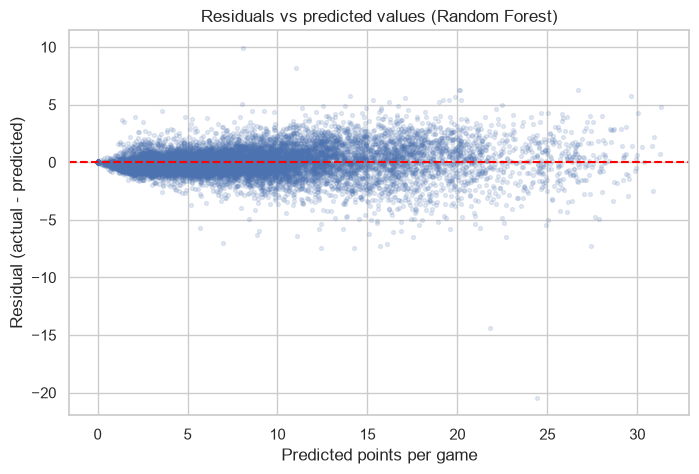

In [6]:
# residuals vs predicted values - looking for patterns or non-constant spread
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.15, s=8)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuals vs predicted values ({best_reg_name})")
plt.xlabel("Predicted points per game")
plt.ylabel("Residual (actual - predicted)")
plt.show()

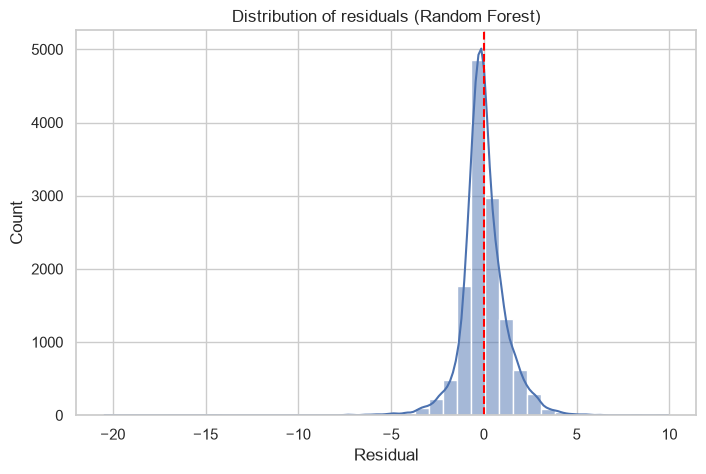

Mean residual: -0.007


In [7]:
# distribution of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title(f"Distribution of residuals ({best_reg_name})")
plt.xlabel("Residual")
plt.show()

print(f"Mean residual: {residuals.mean():.3f}")

**Discussion (residuals).** The mean residual is **-0.007**, essentially
zero, so the model is not systematically biased upward or downward overall - a good
sign that it is well-calibrated on average.

The residuals-vs-predicted scatter shows a clear **funnel shape**: residuals are
tightly packed near zero for low predicted values and spread much wider as
predicted points increase. This is textbook **heteroscedasticity** - the variance
of the errors is not constant. It makes basketball sense: a player predicted at 3
points per game has little room to deviate, while a player predicted at 25 points
per game can realistically land anywhere from 18 to 32, so the absolute error grows
with the predicted value.

The residual distribution is sharply peaked at zero with long tails on both sides,
meaning most predictions are very accurate but a minority are badly wrong. The
clearest **high-error sector** is high-usage players (quantified in 1.2): players
who carry a large share of their team's offence are harder to predict, because
their output depends on matchups, shooting variance and in-season role changes that
season-average features cannot capture.

## 1.2 Error as a function of features

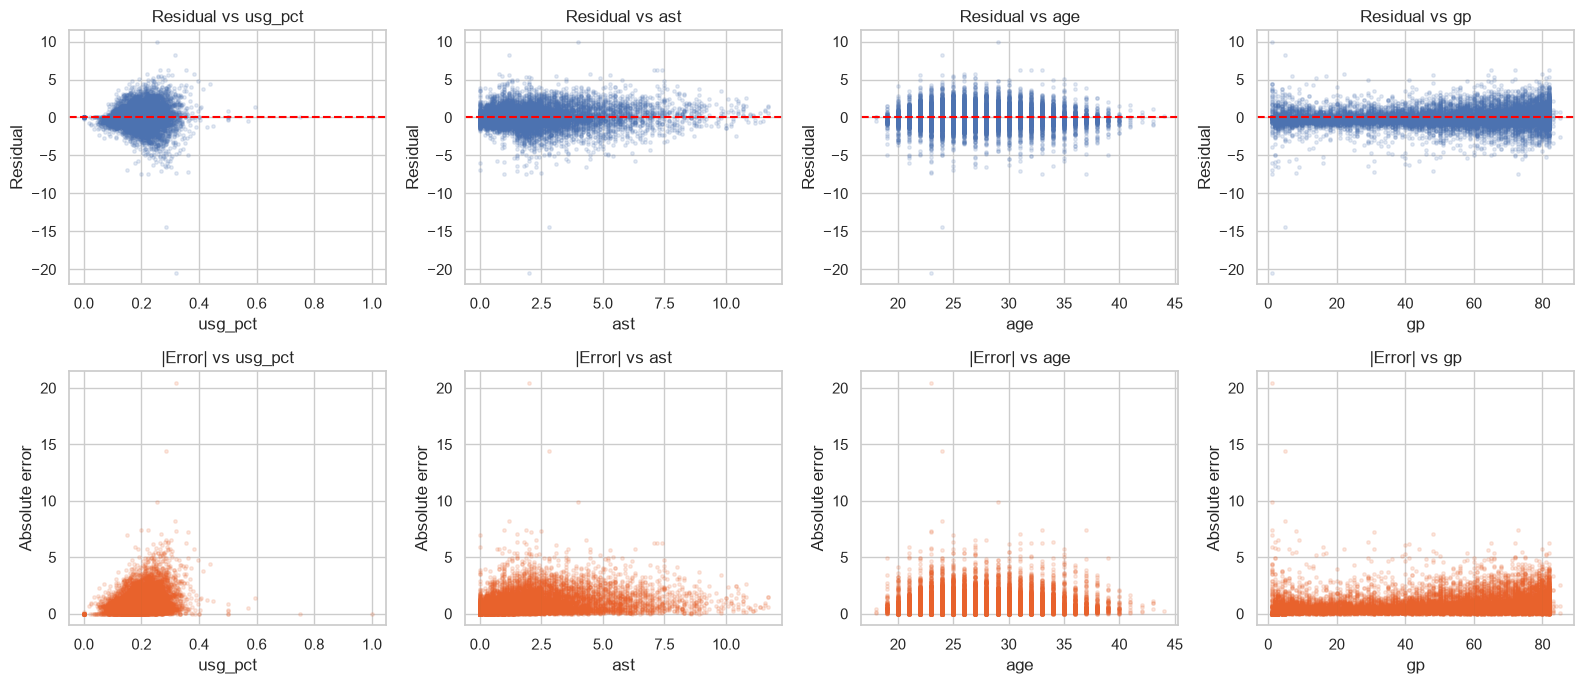

In [8]:
# residual and absolute error vs a few key features
key_features = [c for c in ["usg_pct", "ast", "age", "gp"] if c in feature_cols]
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(2, len(key_features), figsize=(4*len(key_features), 7))
for i, col in enumerate(key_features):
    axes[0, i].scatter(model_df[col], residuals, alpha=0.15, s=6)
    axes[0, i].axhline(0, color="red", linestyle="--")
    axes[0, i].set_title(f"Residual vs {col}")
    axes[0, i].set_xlabel(col); axes[0, i].set_ylabel("Residual")

    axes[1, i].scatter(model_df[col], abs_errors, alpha=0.15, s=6, color="#e8622c")
    axes[1, i].set_title(f"|Error| vs {col}")
    axes[1, i].set_xlabel(col); axes[1, i].set_ylabel("Absolute error")
plt.tight_layout()
plt.show()

**Discussion (error vs features).** Of the four features examined,
**`usg_pct` shows the clearest pattern**: absolute error correlates with usage rate
at **r=0.32**, more than twice the correlation with games played (`gp`, r=0.15).
The `|Error| vs usg_pct` panel shows a widening cone - error is small and tight for
low-usage players and fans out sharply above roughly 0.25 usage.

This is a genuine **feature-dependent error pattern**, not random noise: the more
of a team's offence a player runs, the more variable his scoring becomes, and the
harder he is to predict from season averages. Crucially, it is **usage, not sample
size**, that drives error - the opposite of the intuitive assumption that errors
come mainly from players with few games.

The relationship is also visibly **non-linear** (error is flat at low usage, then
rises steeply past a threshold). A linear model cannot represent this bend, while
Random Forest can split on it directly - another concrete reason for the
performance gap seen in 1.0. Residuals against `age` and `ast` show no comparable
structure, confirming usage rate as the dominant driver.

## 1.3 Analysis of extreme errors

In [9]:
# top 5% largest absolute errors
threshold_95 = np.percentile(abs_errors, 95)
extreme_idx = np.where(abs_errors >= threshold_95)[0]
extreme_df = model_df.iloc[extreme_idx].copy()
extreme_df["predicted_pts"] = y_pred[extreme_idx]
extreme_df["residual"] = residuals[extreme_idx]
extreme_df["abs_error"] = abs_errors[extreme_idx]

print(f"Top 5% errors: {len(extreme_idx)} rows, threshold = {threshold_95:.2f} points")
cols_to_show = ["pts", "predicted_pts", "residual", "gp", "usg_pct", "ast", "age"]
extreme_df.sort_values("abs_error", ascending=False)[cols_to_show].head(10)

Top 5% errors: 643 rows, threshold = 2.51 points


,pts,predicted_pts,residual,gp,usg_pct,ast,age
1151,4.0,24.440812,-20.440812,1,0.320,2.0,23
11820,7.4,21.797679,-14.397679,5,0.287,2.8,24
10026,18.0,8.062172,9.937828,1,0.254,4.0,29
7011,19.2,11.021752,8.178248,5,0.317,1.2,24
9889,6.8,14.256016,-7.456016,73,0.223,1.9,37
7231,5.0,12.407752,-7.407752,1,0.200,1.0,33
8910,8.4,15.687920,-7.287920,8,0.320,2.5,23
9487,20.2,27.438473,-7.238473,31,0.363,2.1,23
11976,9.0,16.092059,-7.092059,48,0.267,1.5,31
433,0.0,6.980100,-6.980100,1,0.149,0.0,25


**Discussion (extreme errors).** The top 5% cutoff is an absolute error
of **2.51 points**, covering **643 rows**. Examining the ten largest errors reveals
two distinct groups:

**Data quality / small-sample issues.** Most of the worst errors involve a very low
`gp`: rows with 1, 1, 1, 5, 5 and 8 games played, all combined with above-average
usage (0.20-0.32 versus 0.185 overall). A player who appeared once and scored 4
points while carrying a 32% usage rate produces a per-game rate that is
statistically meaningless - the model, trained on season-long patterns, has no way
to anticipate it. These are not data-entry errors, but the *target itself* is
unreliable for these rows.

**Rare but real cases.** Row 9889 (age 37, 73 games, 6.8 actual vs 14.3 predicted)
is a different story: a full-season veteran whose role shifted away from scoring.
The model over-predicts because his other stats still resemble those of a primary
scorer. This is a genuine **model limitation** - the features do not encode role
changes late in a career.

Notably, the mean `gp` across *all* 643 extreme rows is 58.7, actually **higher**
than the dataset average of 51.2. So while the very worst individual errors are
small-sample cases, the broader 5% tail is not dominated by them - consistent with
the finding in 1.2 that usage rate matters more than sample size.

## 1.4 Statistical properties of the errors

In [10]:
mae_val = mean_absolute_error(y_reg, y_pred)
std_val = residuals.std()
skew_val = stats.skew(residuals)
kurt_val = stats.kurtosis(residuals)

print(f"MAE:      {mae_val:.3f}")
print(f"Std of residuals: {std_val:.3f}")
print(f"Skewness: {skew_val:.3f}")
print(f"Kurtosis: {kurt_val:.3f}")

MAE:      0.823
Std of residuals: 1.196
Skewness: -0.463
Kurtosis: 11.924


**Interpretation.** The MAE is **0.823 points**, the standard deviation
of residuals is **1.196**, skewness is **-0.463** and kurtosis is **11.924**.

The mildly negative **skewness** means the residual distribution has a slightly
heavier left tail: the model somewhat more often produces large *over*-predictions
(actual far below predicted) than large under-predictions. This matches the extreme
error table, where the biggest errors were cases like a predicted 24.4 against an
actual 4.0. It indicates a mild systematic bias toward over-predicting unusual
players rather than under-predicting them.

The **kurtosis of 11.924** is far above the 0 of a normal distribution - very
**heavy tails**. In practice this means a small number of very large errors
dominate the tail behaviour: most predictions are within about one point, but the
rare failures are dramatic. Heavy tails signal **instability**: the model is highly
reliable for typical players but can be substantially wrong for unusual profiles
(low-sample or high-usage seasons), so a single average error figure like the MAE
understates the risk on individual predictions.

# Part 2 — Classification Error Analysis

We use **Logistic Regression** to predict `good_net_rating` (1 if net_rating >
0). The same 5-fold cross-validation is used, with out-of-fold predicted
probabilities so every prediction comes from a model that never saw that row.

In [11]:
X_clf = model_df[feature_cols].values
y_clf = model_df["good_net_rating"].values

clf_model = LogisticRegression(max_iter=2000)
# predict_proba via cross-validation: get out-of-fold probability of class 1
proba_oof = np.zeros(len(y_clf))
for train_idx, test_idx in kf.split(X_clf):
    clf_model.fit(X_clf[train_idx], y_clf[train_idx])
    proba_oof[test_idx] = clf_model.predict_proba(X_clf[test_idx])[:, 1]

pred_default = (proba_oof >= 0.5).astype(int)
print("Accuracy at 0.5 threshold:", (pred_default == y_clf).mean().round(3))

Accuracy at 0.5 threshold: 0.662


## 3.1 Confusion matrix analysis

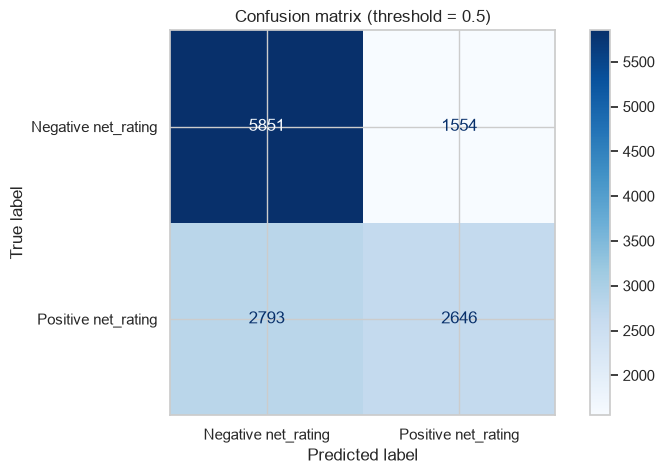

True negatives:  5851
False positives: 1554  (predicted good, actually not)
False negatives: 2793  (predicted not-good, actually good)
True positives:  2646


In [12]:
cm = confusion_matrix(y_clf, pred_default)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative net_rating", "Positive net_rating"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (threshold = 0.5)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn}")
print(f"False positives: {fp}  (predicted good, actually not)")
print(f"False negatives: {fn}  (predicted not-good, actually good)")
print(f"True positives:  {tp}")

**Discussion.** At the default 0.5 threshold the confusion matrix gives
**5,851 true negatives, 1,554 false positives, 2,793 false negatives and 2,646 true
positives** (66.2% accuracy).

**False negatives are nearly twice as common as false positives** (2,793 vs 1,554).
In plain terms: the model much more often tells us a genuinely valuable player is
*not* valuable than the reverse. This asymmetry comes partly from the class
imbalance (57.7% negative vs 42.3% positive) - the model leans toward predicting
the majority class.

**Which error is more critical** depends on the use case. For **scouting**, a false
negative is worse: overlooking a player who genuinely improves his team is a missed
opportunity a competitor may take. For **roster cuts**, a false positive is worse:
keeping a player who does not actually help costs a roster spot and salary. Since
the model's errors already skew toward false negatives, a scouting application
would want to *lower* the decision threshold (see 3.4).

**Systematic failure region.** The model fails most on players whose contribution
comes from team fit rather than individual production - net_rating is a team-level
statistic, and the features here describe only the individual, so no amount of
model tuning can recover information the data does not contain.

## 3.2 Probability-based analysis

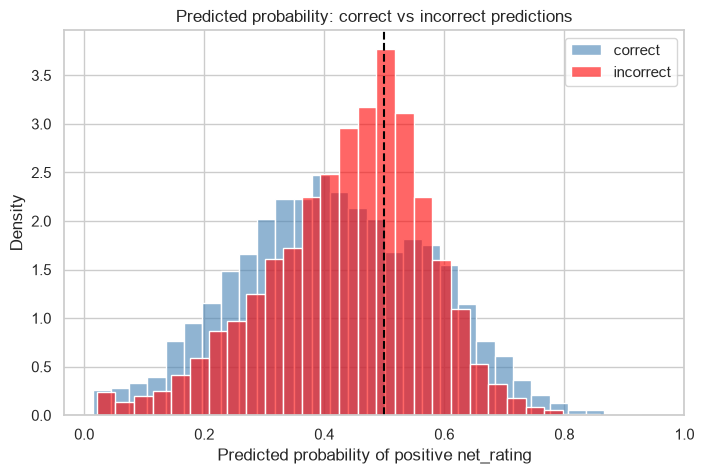

In [13]:
# compare predicted probabilities for correct vs incorrect predictions
correct = pred_default == y_clf
plt.figure(figsize=(8, 5))
sns.histplot(proba_oof[correct], bins=30, color="steelblue", label="correct", alpha=0.6, stat="density")
sns.histplot(proba_oof[~correct], bins=30, color="red", label="incorrect", alpha=0.6, stat="density")
plt.axvline(0.5, color="black", linestyle="--")
plt.title("Predicted probability: correct vs incorrect predictions")
plt.xlabel("Predicted probability of positive net_rating")
plt.legend()
plt.show()

**Discussion.** The two distributions overlap heavily, but with a clear
difference in shape. **Correct** predictions extend further toward both extremes
(near 0 and above 0.7) - when the model is confident, it is usually right.
**Incorrect** predictions are concentrated in the middle of the range, peaking
right around the 0.5 decision line.

This is the reassuring pattern: most errors are **borderline, low-confidence
cases** where the model is genuinely uncertain and the predicted probability sits
close to the threshold, rather than **high-confidence errors** where the model
would be confidently wrong. Few mistakes occur at probabilities below 0.2 or above
0.8.

Practically, this means the predicted probability is a usable measure of
reliability: predictions near 0.5 should be treated as "unknown" rather than acted
on, while confident predictions can be trusted more. It also explains why the
overall accuracy is limited - a large share of player-seasons genuinely sit in the
ambiguous middle, where individual stats simply do not determine whether the team
performed better with that player on the court.

## 3.3 Error as a function of features

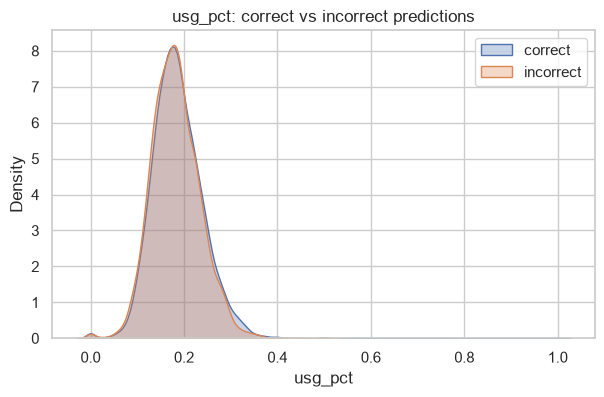

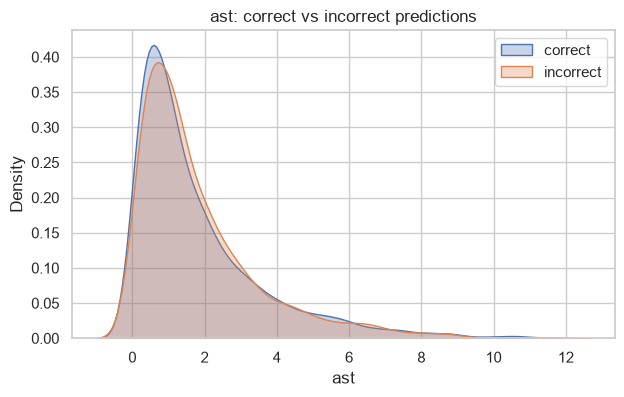

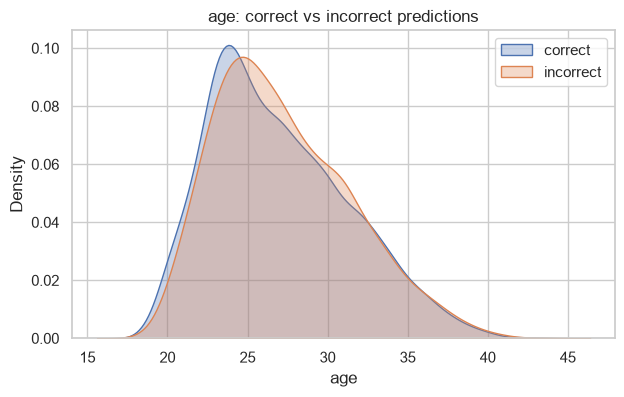

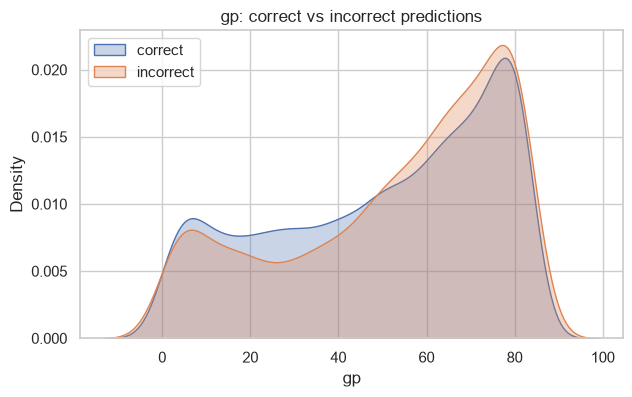

In [14]:
# compare feature distributions for correct vs incorrect predictions
for col in key_features:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(model_df.loc[correct, col], label="correct", fill=True, alpha=0.3)
    sns.kdeplot(model_df.loc[~correct, col], label="incorrect", fill=True, alpha=0.3)
    plt.title(f"{col}: correct vs incorrect predictions")
    plt.xlabel(col)
    plt.legend()
    plt.show()

**Discussion.** The feature means barely differ between correct and
incorrect groups (e.g. usg_pct 0.186 vs 0.182, ast 1.82 vs 1.83, age 27.0 vs 27.2),
except `gp`: correct predictions average 50.3 games vs 52.9 for incorrect ones - a
small but consistent gap. None of these differences are large, which itself is an
insight: misclassification here is **not concentrated in an obvious region of
feature space** the way the regression errors were concentrated in high-usage
players. This suggests net_rating depends on factors largely outside these
features (teammates, matchups, coaching), so no single stat marks a "danger zone"
for the classifier the way usage rate did for the regressor.

## 3.4 Threshold sensitivity analysis

In [15]:
# precision, recall, F1 across thresholds 0.1 to 0.9
thresholds = np.arange(0.1, 1.0, 0.1)
threshold_rows = []
for t in thresholds:
    pred_t = (proba_oof >= t).astype(int)
    threshold_rows.append({
        "threshold": round(t, 1),
        "precision": precision_score(y_clf, pred_t, zero_division=0),
        "recall": recall_score(y_clf, pred_t, zero_division=0),
        "f1": f1_score(y_clf, pred_t, zero_division=0),
        "mcc": matthews_corrcoef(y_clf, pred_t),
    })
threshold_df = pd.DataFrame(threshold_rows).round(3)
threshold_df

,threshold,precision,recall,f1,mcc
0,0.1,0.428,0.989,0.597,0.057
1,0.2,0.441,0.958,0.604,0.120
2,0.3,0.473,0.878,0.614,0.191
3,0.4,0.538,0.727,0.618,0.267
4,0.5,0.630,0.486,0.549,0.291
5,0.6,0.756,0.212,0.331,0.247
6,0.7,0.843,0.051,0.097,0.138
7,0.8,0.870,0.007,0.015,0.054
8,0.9,0.667,0.000,0.001,0.008


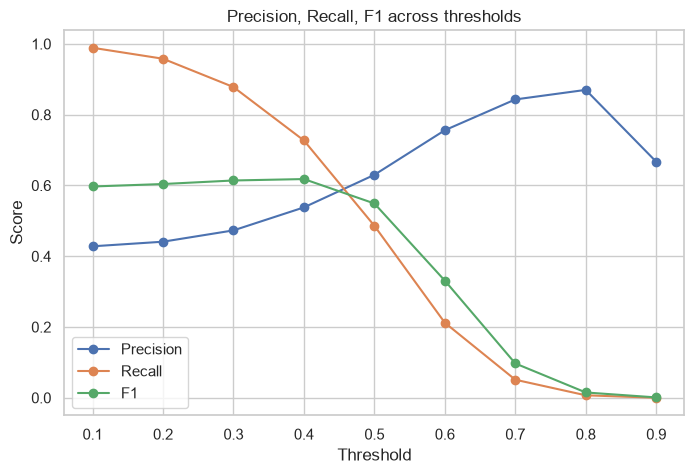

In [16]:
# plot precision, recall, F1 across thresholds
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Precision, Recall, F1 across thresholds")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.legend()
plt.show()

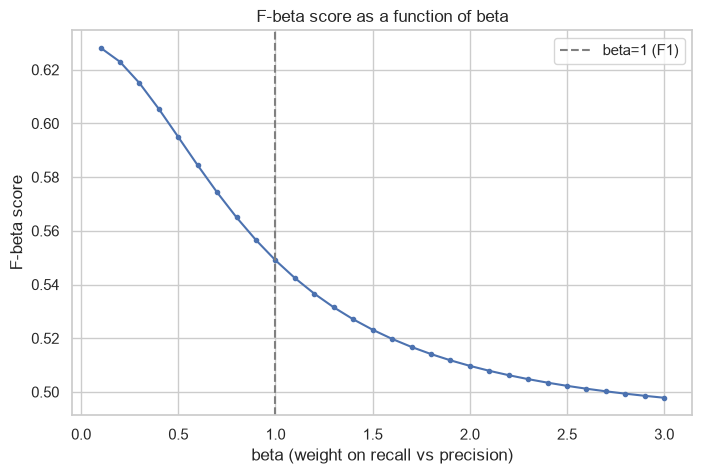

In [17]:
# F-beta score as a function of beta, at the default 0.5 threshold
betas = np.arange(0.1, 3.1, 0.1)
fbeta_scores = [fbeta_score(y_clf, pred_default, beta=b, zero_division=0) for b in betas]
plt.figure(figsize=(8, 5))
plt.plot(betas, fbeta_scores, marker=".")
plt.axvline(1, color="gray", linestyle="--", label="beta=1 (F1)")
plt.title("F-beta score as a function of beta")
plt.xlabel("beta (weight on recall vs precision)")
plt.ylabel("F-beta score")
plt.legend()
plt.show()

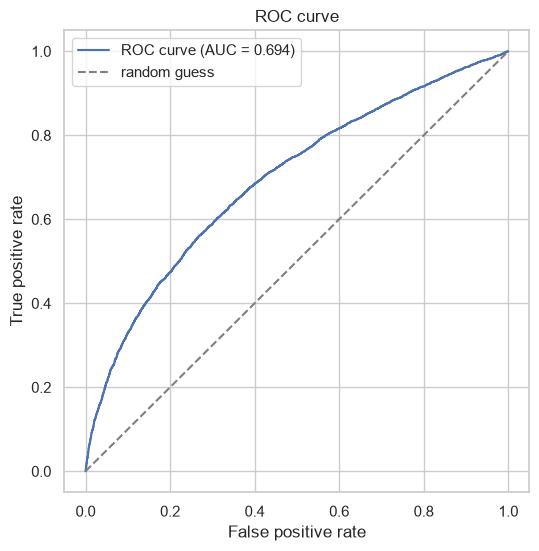

In [18]:
# ROC curve and AUC
fpr, tpr, roc_thresholds = roc_curve(y_clf, proba_oof)
auc = roc_auc_score(y_clf, proba_oof)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random guess")
plt.title("ROC curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

**Discussion.** F1 is fairly stable between thresholds 0.1-0.4
(0.597-0.618, peaking at **0.4**), then drops sharply from 0.5 onward (0.55, then
0.33, 0.10, 0.02, 0.0) - the model rarely assigns probabilities above ~0.6, so
raising the threshold quickly starves recall. This means 0.1-0.4 is the **stable
operating region**, while anything above ~0.5 is an **unstable region** where a
small threshold change causes a large swing in performance. AUC = 0.694 - clearly
better than random guessing (0.5) but far from perfect separation (1.0), showing
the two classes overlap substantially in feature space. Practically: lowering the
threshold below 0.5 trades some precision for much better recall here, which given
the false-negative-heavy confusion matrix above may be the more useful setting for
a scouting use case that does not want to miss good players.

## 3.5 Discussion — critical comparison of the models

**Regression.** Random Forest (MAE 0.82, R²=0.96) clearly beats Decision Tree and
Linear Regression, showing the points-per-game relationship has real non-linear
structure that a linear model misses. The main failure mode is **high-usage
players**, whose error correlates with usage rate (r=0.32) far more than with
sample size (r=0.15) - the opposite of what might be assumed.

**Classification.** Logistic Regression reaches 66.2% accuracy and AUC=0.694 -
a real but limited ability to predict `net_rating` from individual stats. False
negatives dominate over false positives, and errors are not concentrated in any
single feature region, suggesting the model is missing information (team context)
rather than misreading the features it has.

**Assumptions.** Linear Regression's linearity assumption is the main
limitation for the regression task; Logistic Regression's implicit linear
decision boundary (in log-odds space) likely explains why AUC tops out around
0.69 rather than higher - the boundary between "good" and "not-good" net_rating
is probably not linear in these features either.

**Bias-variance.** Random Forest's ensemble averaging is the clear winner for
reducing variance without adding much bias, matching the theory.

**Sensitivity to outliers/noise.** Both regression and classification results
point to the same lesson: the models are least reliable exactly where the
underlying signal is noisiest (low-sample player-seasons, team-context-dependent
outcomes) - not a flaw in the models themselves but a property of the data.

**Interpretability vs performance trade-off.** Linear/Logistic Regression give
simple, interpretable coefficients; Random Forest trades that away for
substantially better predictive performance. For a scouting report meant to
explain *why* a prediction was made, the simpler model may still be preferable
despite its lower accuracy.

**Preferred model.** Random Forest for the regression task (its performance
advantage is large and consistent); Logistic Regression for the classification
task mainly because of its interpretability, given the classifier's accuracy is
already limited by the coarse-grained feature set rather than model choice.

**What I learned from the modeling stage.** The biggest error source was not
data volume (small `gp` samples mattered less than expected) but the *type* of
outcome being predicted: an individually-measured stat (points) is far more
predictable than a team-dependent stat (net_rating) from individual features
alone - a reminder that the ceiling on model performance is often set by the
problem formulation, not the algorithm.

## 4. Final Reflection

**1. Where does the model fail most?**
For regression: high-usage players and very-low-game-count player-seasons, where
per-game rates are volatile. For classification: borderline cases where the
predicted probability sits near 0.3-0.6 - the model is genuinely unsure, and that
uncertainty is where most misclassifications happen.

**2. Are failures due to data, model, or formulation?**
Mostly a mix of **data** (small-sample per-game rates are inherently noisy - no
model fixes that) and **problem formulation** (net_rating is a team-level,
context-dependent statistic; predicting it from purely individual box-score stats
leaves out information the model would need - teammates, matchups, coaching
scheme). The **model** choice mattered most for the regression task, where
switching from linear to ensemble methods cut MAE by 40%, showing real non-linear
structure Linear Regression could not reach.

**3. What improvements would you propose?**
Weight or filter observations by `gp` so unstable small-sample rows do not
dominate the extreme-error analysis; add team-level or lineup-context features for
the classification task; try a non-linear classifier (e.g. Random Forest
Classifier) to test whether the ~0.69 AUC ceiling is a data limit or a model limit;
tune the decision threshold to the real-world cost of missing a good player versus
over-rating a weak one, rather than defaulting to 0.5.

**4. What insights did you gain in your analysis?**
Model choice mattered enormously for regression (non-linear methods captured real
structure), but for classification the ceiling seemed to be the *available
features* rather than the *algorithm* - a reminder that systematic error analysis
can reveal whether more modeling effort or more/better data is the right next
step, which a single accuracy number would never show.